In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os

from hiatus.config import plots_dir

import warnings

warnings.filterwarnings('ignore')

sns.set_style(style="darkgrid")

In [2]:
plots_dir.mkdir(exist_ok=True)

In [21]:
experiment_suffix = "PromptRemix-TFS_AR0"
genres = ['ar_twitter_1', 'saudinewsnet']
styles = [1, 2, 3]

file_paths = {}

for genre in genres:
    file_paths[genre] = {'input_queries': [], 'privatized': []}
    for style in styles:
        pipeline_suffix = f"promptremix-tfs_ar0-{style}"

        command = [
            "python",
            "/mmfs1/home/hardiksr/repository/hiatus/scripts/4-obfuscation/get_hrs_paths.py",
            "--genre", genre,
            "--language", "ar",
            "--pipeline-suffix", pipeline_suffix
        ]
        result = subprocess.run(command, capture_output=True, text=True)
        paths = result.stdout.strip().split(" ")

        if len(paths) == 2:
            file_paths[genre]['input_queries'].append(paths[0])
            file_paths[genre]['privatized'].append(paths[1])

In [4]:
text_lengths = {"genre": [], "style": [], "document_id": [], "type": [], "text_length": []}

for genre, paths in file_paths.items():
    for style_idx, (input_queries_path, privatized_path) in enumerate(zip(paths['input_queries'], paths['privatized']), start=1):
        input_queries_data = pd.read_json(input_queries_path, lines=True)
        privatized_data = pd.read_json(privatized_path, lines=True)

        merged_data = pd.merge(input_queries_data, privatized_data, on='documentID', suffixes=('_input', '_privatized'))

        merged_data['input_text_length'] = merged_data['fullText_input'].apply(len)
        merged_data['privatized_text_length'] = merged_data['PIIobfuscated'].apply(len)

        text_lengths['genre'].extend([genre] * len(merged_data) * 2)
        text_lengths['style'].extend([style_idx] * len(merged_data) * 2)
        text_lengths['document_id'].extend(merged_data['documentID'].tolist() * 2)
        text_lengths['type'].extend(['input_queries'] * len(merged_data) + ['privatized'] * len(merged_data))
        text_lengths['text_length'].extend(merged_data['input_text_length'].tolist() + merged_data['privatized_text_length'].tolist())

text_lengths_df = pd.DataFrame(text_lengths)
text_lengths_df.shape

(1902, 5)

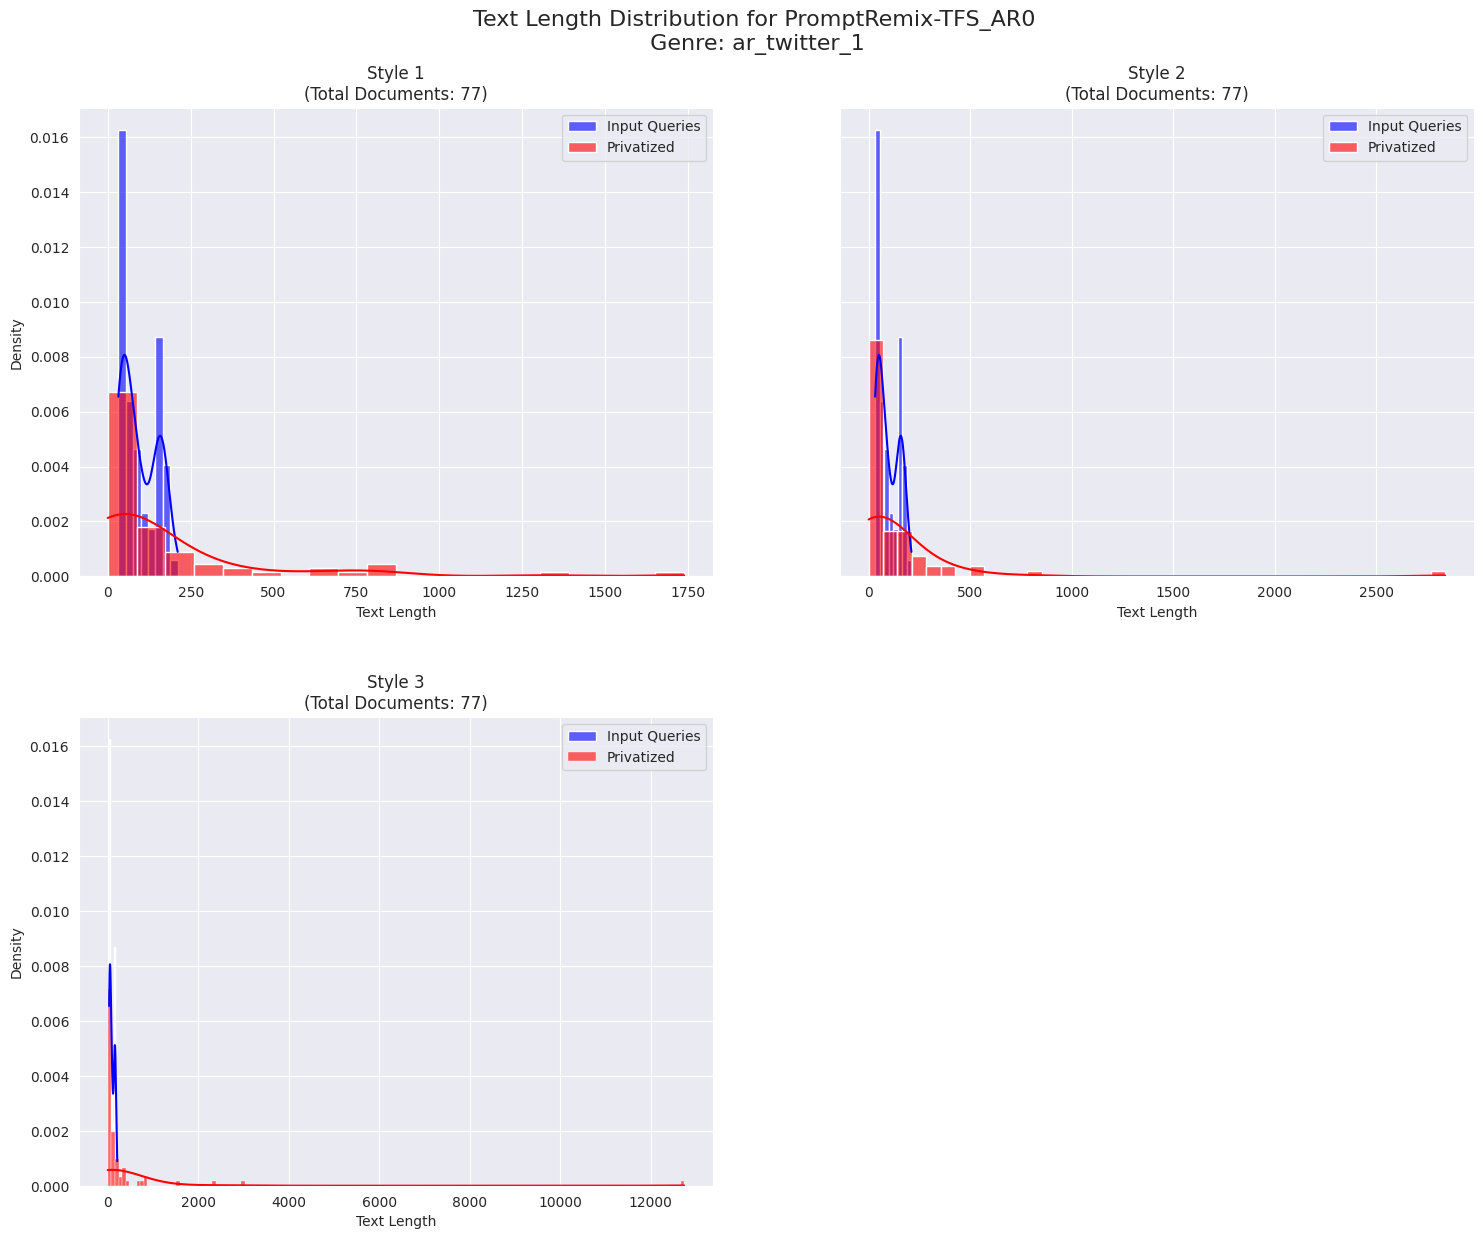

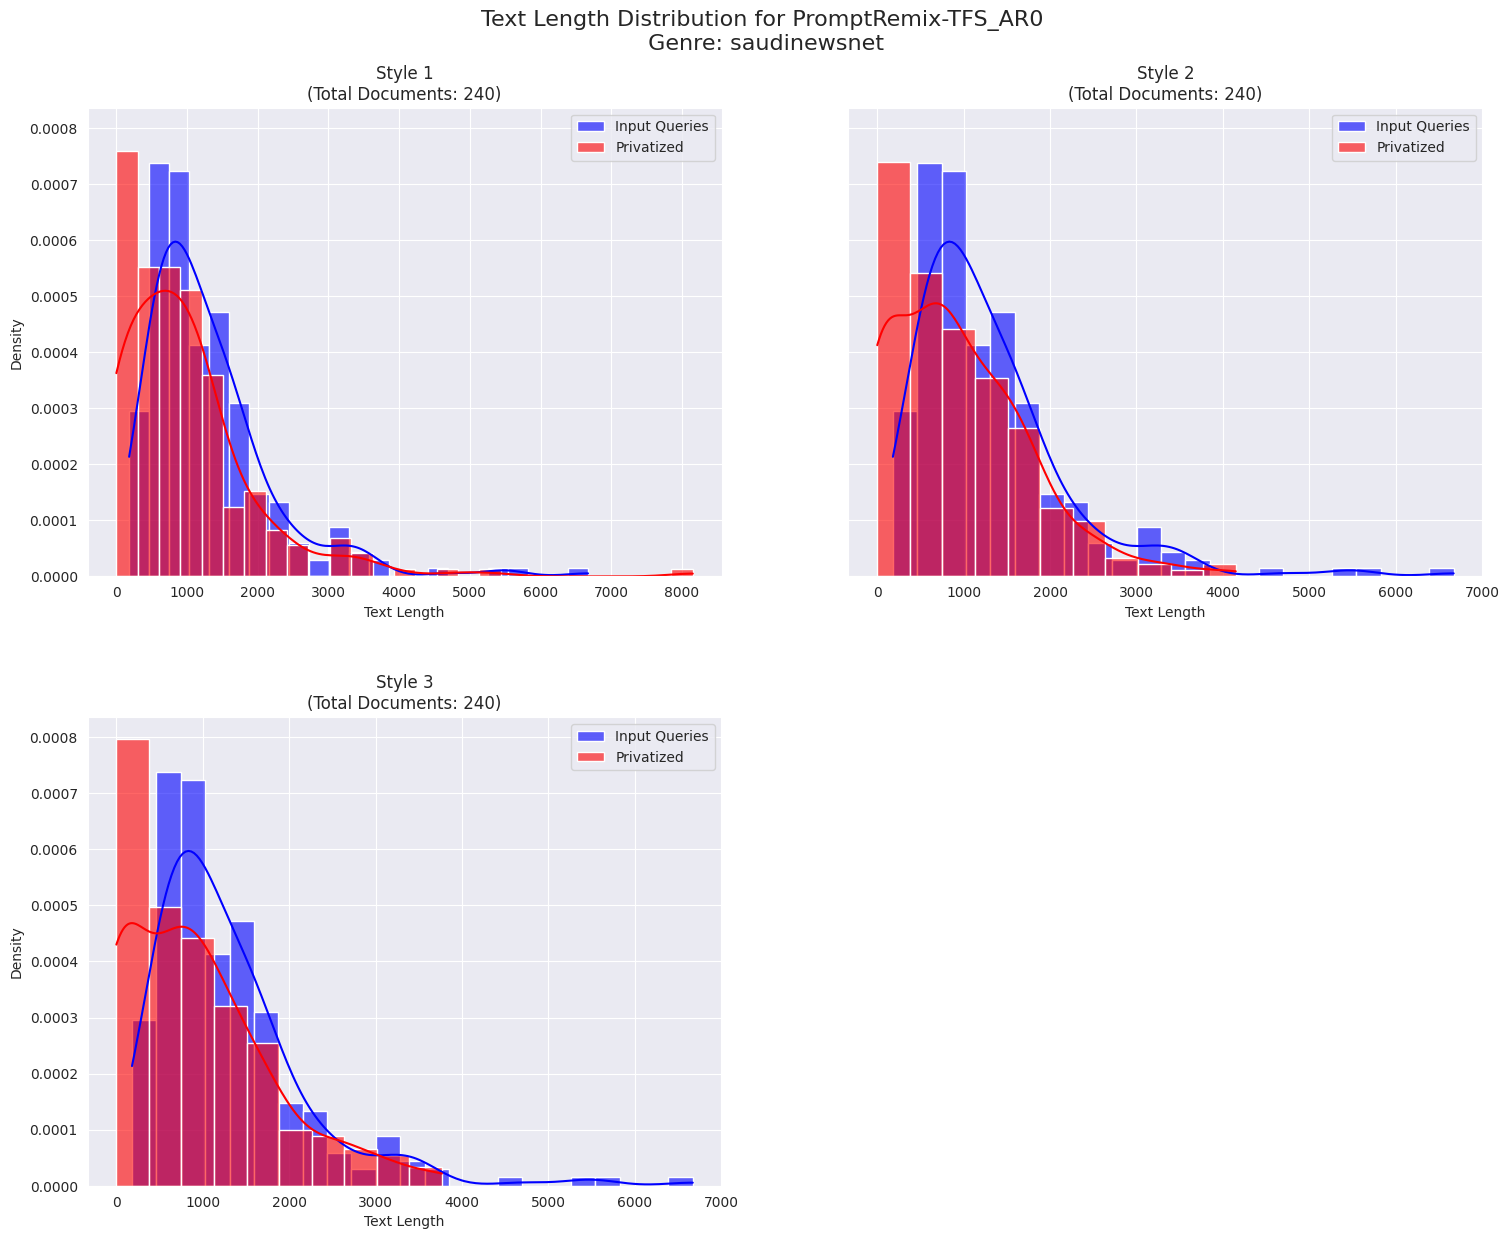

In [22]:
for genre in text_lengths_df['genre'].unique():
    genre_data = text_lengths_df[text_lengths_df['genre'] == genre]

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
    fig.subplots_adjust(hspace=0.3)
    fig.suptitle(f'Text Length Distribution for {experiment_suffix}\n Genre: {genre}', fontsize=16, y=0.95)

    for idx, style in enumerate(genre_data['style'].unique()):
        row, col = divmod(idx, 2)
        style_data = genre_data[genre_data['style'] == style]

        sns.histplot(
            style_data[style_data['type'] == 'input_queries']['text_length'],
            color='blue', label='Input Queries', kde=True, stat="density", alpha=0.6, ax=axes[row, col]
        )
        sns.histplot(
            style_data[style_data['type'] == 'privatized']['text_length'],
            color='red', label='Privatized', kde=True, stat="density", alpha=0.6, ax=axes[row, col]
        )

        axes[row, col].set_title(f'Style {style}\n(Total Documents: {len(style_data["document_id"].unique())})')
        axes[row, col].set_xlabel('Text Length')
        axes[row, col].legend()

    for ax in axes.flat[len(genre_data['style'].unique()):]:
        ax.axis('off')

    axes[0, 0].set_ylabel('Density')
    
    save_path = os.path.join(plots_dir, f"text_length_histogram_{genre}.pdf")
    plt.savefig(save_path)
    plt.show()

In [6]:
text_lengths_df.head()

,genre,style,document_id,type,text_length
0,ar_twitter_1,1,ed678681-e171-52b6-a982-c1703d285f16,input_queries,47
1,ar_twitter_1,1,f8905a61-cf3f-5991-8d06-57cc0b177567,input_queries,76
2,ar_twitter_1,1,a5662de9-e09b-555e-b97c-402a8958a027,input_queries,54
3,ar_twitter_1,1,4f529b18-2952-54ff-8500-6c9a775ec236,input_queries,40
4,ar_twitter_1,1,3f61c4c4-58b2-50a7-9612-1661d10f5ce7,input_queries,54


In [8]:
num_cols = ['style', 'text_length']
text_lengths_df_agg = text_lengths_df.groupby(['document_id', 'type'], as_index=False)[num_cols].mean()
text_length_diff = text_lengths_df_agg.pivot(index='document_id', columns='type', values='text_length')
text_length_diff['length_change'] = text_length_diff['privatized'] - text_length_diff['input_queries']

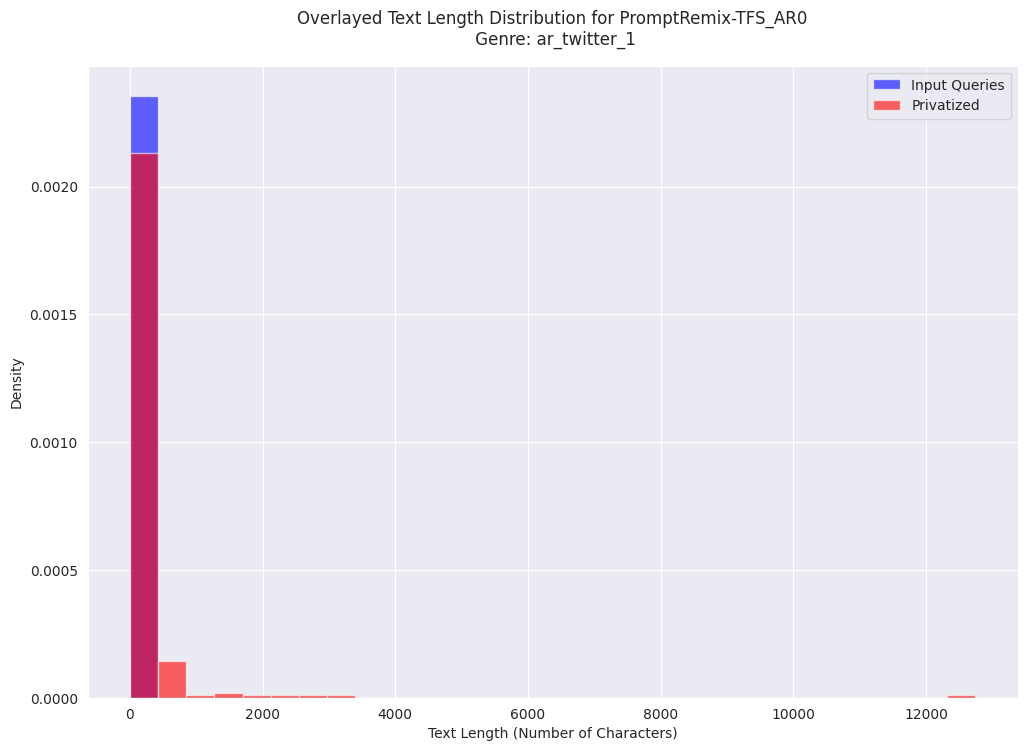

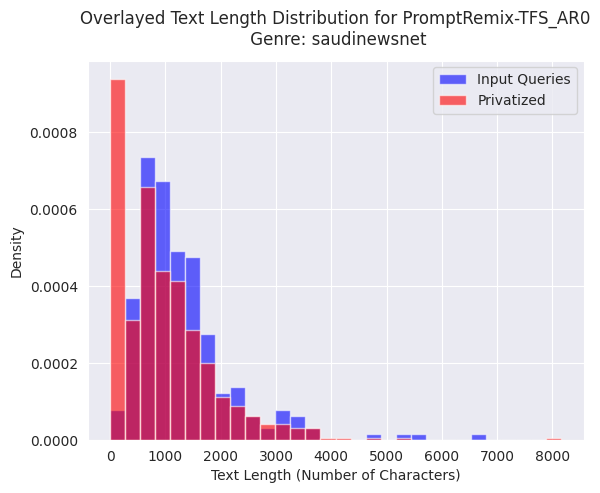

In [ ]:
plt.figure(figsize=(12, 8))

for genre in text_lengths_df['genre'].unique():
    genre_data = text_lengths_df[text_lengths_df['genre'] == genre]

    x_min = min(genre_data['text_length'])
    x_max = max(genre_data['text_length'])

    plt.subplots_adjust(top=0.9)
    plt.hist(
        genre_data[genre_data['type'] == 'input_queries']['text_length'],
        bins=30, alpha=0.6, label='Input Queries', color='blue', density=True, range=(x_min, x_max)
    )
    plt.hist(
        genre_data[genre_data['type'] == 'privatized']['text_length'],
        bins=30, alpha=0.6, label='Privatized', color='red', density=True, range=(x_min, x_max)
    )

    plt.title(f'Overlayed Text Length Distribution for {experiment_suffix}\n Genre: {genre}', y=1.02)
    plt.xlabel('Text Length (Number of Characters)')
    plt.ylabel('Density')
    plt.legend()

    save_path = os.path.join(plots_dir, f"overlayed_text_length_dist_{genre}.pdf")

    plt.savefig(save_path)
    plt.show()